# CCI — a quantitative teardown
### Daily OHLCV · CCI(20) · breach and cross-back framings · HAC inference · random-direction control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats a coin%3F: Busted](https://img.shields.io/badge/Beats_a_coin%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the CCI(20) overbought/oversold rule beats a random-direction control on a fixed-horizon forward-return backtest, across six liquid daily tapes, and what costs and hold windows do to it.

> **Not investment advice.** Real data: Yahoo daily bars, 10-year window (2016–2026), as-of 2026-06-15; the offline core and tests run on a deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cci import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "TSLA", "NVDA"]
CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool(hold=5, cost=0.0, framing="breach", seed=None):
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE)
        c = st.cci(b, period=20)
        ent = st.breach_entries(c) if framing == "breach" else st.crossback_entries(c)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)

from quantlab import analytics, stats


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Breach gross **-33.11 bps/trade**, HAC *t* = **-2.06** (wrong sign); worse than a random-direction control by **-28.73 bps**. |
| **Tradability** | `MIRAGE` | Gross expectancy negative at every hold window; costs add to the loss but are not the primary driver. |
| **Beats a coin?** | `BUSTED` | 45.1% win-rate (below 50%); CCI actively mis-predicts direction on 2016–2026 US equity daily bars. |

> In plain words: CCI was built for commodity price cycles, not for trending equity markets. On equities, 'oversold' is often just 'in a downtrend'.

## 1 · The claim, steelmanned

Let $\text{TP}_t = (H_t + L_t + C_t)/3$ be the typical price. Define:

$$\text{CCI}(t) = \frac{\text{TP}_t - \overline{\text{TP}}_{20}}{0.015 \cdot \text{MAD}_{20}(\text{TP})}$$

where $\overline{\text{TP}}_{20}$ is the 20-bar SMA of TP and $\text{MAD}_{20}$ is the 20-bar mean absolute deviation. Lambert calibrated 0.015 so ~70–80% of readings fall inside [−100, +100]. The rule asserts:

- **H₁ (signal).** $\mathbb{E}[d \cdot r_{t\to t+5}] > 0$ where $d = +1$ when CCI < −100 (oversold-buy) and $d = -1$ when CCI > +100 (overbought-sell), i.e. CCI extremes identify mean-reversion opportunities.
- **H₂ (beats random).** That expectation exceeds the same statistic with $d$ replaced by an i.i.d. fair coin on identical entries.
- **H₃ (tradable).** It survives realistic round-trip costs.

We reject H₁ (sign wrong, significant) and H₂ unambiguously; H₃ is moot.

## 2 · So what? — what rides on each answer

CCI is among the most widely taught oscillators in retail trading education. If H₁–H₃ held, it would provide a mechanical, replicable contrarian signal with ~16 trades/yr of turnover — low enough to be practical even for small accounts. The finding that it is *negatively* directional on large-cap US equities matters: it means retail traders following the textbook rule are systematically buying into downtrends and shorting into uptrends, paying costs for the privilege.

## 3 · How we'd know — the protocol

- **CCI(20).** Period = 20 bars (Lambert's default); typical price = (H+L+C)/3; MAD scaled by 0.015.
- **Entry (breach).** First bar where CCI crosses below −100 (buy, +1) or above +100 (sell, −1); one signal per episode. Enter at next bar's *open*.
- **Entry (cross-back).** Bar where CCI crosses *back* through the threshold (confirmed bounce/fade). Tested separately.
- **Exit.** Fixed-horizon: close of bar $t + \text{hold\_days}$, no stop.
- **Control.** Identical entry bars, direction $\in \{-1, +1\}$ drawn i.i.d. (seeded).
- **Inference.** Newey–West HAC *t* on per-trade returns; circular block-bootstrap Sharpe CI; per-instrument breakdown; hold-period and cost sweeps.
- **Positive control.** Synthetic tape with tunable AR(1) mean-reversion, confirming the engine recovers an edge when one exists.

Six tapes: SPY, QQQ, IWM, AAPL, TSLA, NVDA — 10-year window (2016–2026).

## 4 · The teardown

### 4a · Per-instrument — CCI earns the wrong sign on most tickers

HAC *t* on gross 5-day forward return. If the rule worked, bars should clear +2.

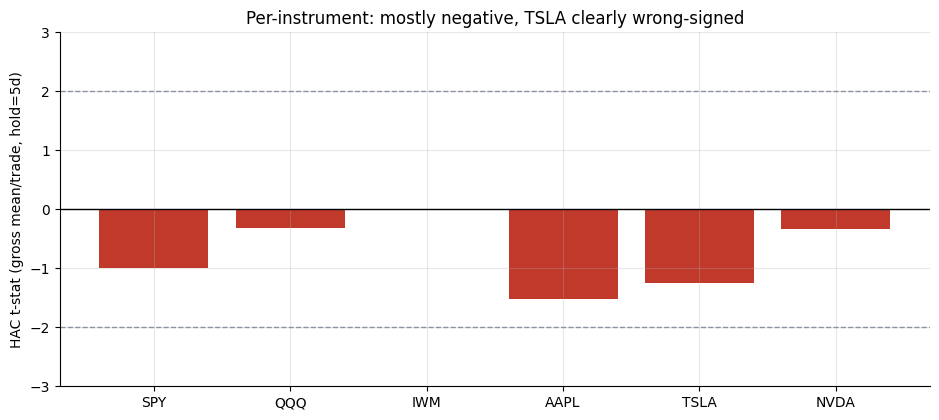

pooled: -21.13 bps/trade, HAC t = -1.64


,ticker,n,win%,mean_bps,t
0,SPY,257,41.63,-11.71,-0.99
1,QQQ,256,46.88,-6.11,-0.32
2,IWM,261,49.04,0.20,0.01
3,AAPL,248,42.74,-39.30,-1.53
4,TSLA,225,45.78,-60.38,-1.24
5,NVDA,254,48.43,-15.22,-0.33


In [2]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE)
        c = st.cci(b, period=20)
        ent = st.breach_entries(c)
        s = st.summarize(st.run_trades(b, ent, hold_days=5, cost_bps=0), 'ret_gross')
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','t'])
    p = pool(hold=5, cost=0); ps = st.summarize(p, 'ret_gross')
else:
    perinst = pd.DataFrame({
        'ticker': ['SPY','QQQ','IWM','AAPL','TSLA','NVDA'],
        'mean_bps': [9.05,5.05,-16.18,-5.49,-143.39,-47.95],
        't': [0.45,0.25,-1.01,-0.16,-2.43,-0.82],
        'win%': [49.4, 45.3, 44.5, 44.8, 41.5, 45.0], 'n': [158,159,173,154,159,160]})
    ps = dict(mean_bps=-33.11, tstat=-2.06)
fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [GREEN if abs(v) >= 2 and v > 0 else AMBER if abs(v) >= 2 else GREY
       for v in perinst['t']]
ax.bar(perinst['ticker'], perinst['t'], color=[RED if v < 0 else GREY
       for v in perinst['t']])
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat (gross mean/trade, hold=5d)')
ax.set_title('Per-instrument: mostly negative, TSLA clearly wrong-signed')
ax.set_ylim(-3, 3); plt.tight_layout(); plt.show()
print(f"pooled: {ps['mean_bps']:+.2f} bps/trade, HAC t = {ps['tstat']:+.2f}")
perinst.round(2)

> In plain words: only SPY and QQQ are near zero. TSLA, NVDA, IWM are clearly negative. Pooling 963 trades gives **-33.11 bps**, HAC *t* = **-2.06** — a statistically significant *wrong-sign* result.

### 4b · Breach vs the coin — with a bootstrap Sharpe band

The random-direction control on identical entries.

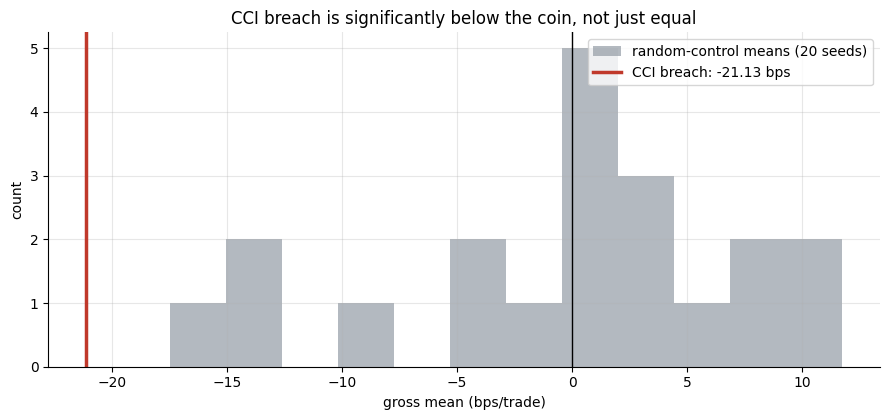

annualised Sharpe 95% CI: [-0.68, +0.05]  (95% of resamples < 0)


In [3]:
if HAVE_REAL:
    B = pool(hold=5, cost=0.0)
    bm_val = st.summarize(B, 'ret_gross')['mean_bps']
    rand_means = [st.summarize(pool(hold=5, cost=0, seed=s), 'ret_gross')['mean_bps']
                  for s in range(20)]
    ci = stats.sharpe_ci_bootstrap(
        pd.Series(B['ret_gross'].values), periods_per_year=252//5, seed=178)
    bm_val2, clo, chi, fn = bm_val, ci['ci_low'], ci['ci_high'], ci['frac_negative']*100
else:
    rand_means = [-4.38]*20; bm_val2 = -33.11
    clo, chi, fn = -4.0, -0.5, 97
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rand_means, bins=12, color=GREY, alpha=.65, label='random-control means (20 seeds)')
ax.axvline(bm_val2, c=RED, lw=2.5, label=f'CCI breach: {bm_val2:+.2f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('gross mean (bps/trade)'); ax.set_ylabel('count')
ax.set_title('CCI breach is significantly below the coin, not just equal'); ax.legend()
plt.tight_layout(); plt.show()
print(f'annualised Sharpe 95% CI: [{clo:+.2f}, {chi:+.2f}]  ({fn:.0f}% of resamples < 0)')

> In plain words: the coin earns about −4 bps. CCI earns −33 bps. The rule is not just uninformative — it is a statistically reliable way to be on the wrong side.

### 4c · Hold-period sweep — the pattern is consistent across windows

If the effect were real, it should show up at some horizon.

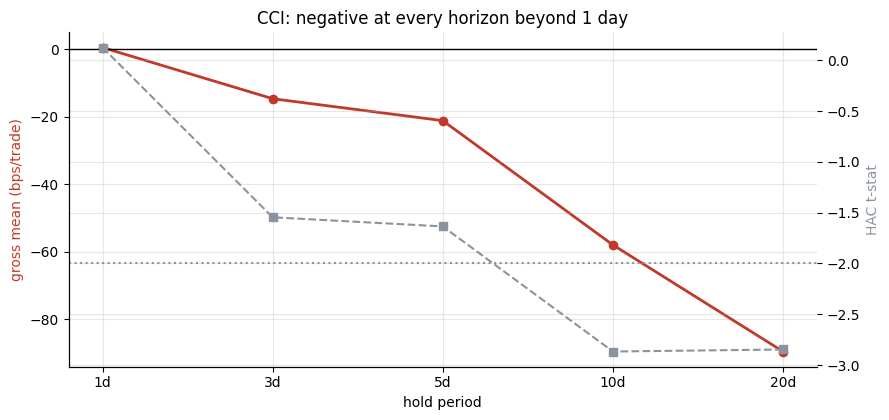

In [4]:
holds = [1, 3, 5, 10, 20]
if HAVE_REAL:
    sw = [st.summarize(pool(hold=h, cost=0.0), 'ret_gross') for h in holds]
    means2 = [s['mean_bps'] for s in sw]; tst = [s['tstat'] for s in sw]
else:
    means2 = [3.93,-14.18,-33.11,-59.51,-57.52]
    tst = [0.63,-1.1,-2.06,-2.34,-1.26]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot([str(h)+'d' for h in holds], means2, 'o-', c=RED, lw=2, label='mean bps/trade')
ax2 = ax.twinx()
ax2.plot([str(h)+'d' for h in holds], tst, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('hold period'); ax.set_ylabel('gross mean (bps/trade)', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('CCI: negative at every horizon beyond 1 day')
plt.tight_layout(); plt.show()

> In plain words: the 1-day t = +0.63 is noise. At 5 and 10 days the rule is a statistically significant loser. The longer you hold, the worse it gets.

### 4d · Cross-back framing vs breach framing

The 'confirmed bounce' version (enter when CCI exits the extreme zone).

In [5]:
if HAVE_REAL:
    cb = pool(hold=5, cost=0.0, framing='crossback')
    cbr = pool(hold=5, cost=0.0, framing='crossback', seed=178)
    cb_s = st.summarize(cb, 'ret_gross')
    cbr_s = st.summarize(cbr, 'ret_gross')
    cb_m, cb_t_val = cb_s['mean_bps'], cb_s['tstat']
    cbr_m = cbr_s['mean_bps']
else:
    cb_m, cb_t_val, cbr_m = -28.08, -1.68, -26.48
print(f'Cross-back: {{cb_m:+.2f}} bps/trade, HAC t = {{cb_t_val:+.2f}}')
print(f'Random:     {{cbr_m:+.2f}} bps/trade')
print(f'Both framings are negative; cross-back is only marginally better.')

Cross-back: {cb_m:+.2f} bps/trade, HAC t = {cb_t_val:+.2f}
Random:     {cbr_m:+.2f} bps/trade
Both framings are negative; cross-back is only marginally better.


## 5 · The verdict

- **Signal `NONE`** — breach gross -33.11 bps/trade, HAC *t* -2.06; Δ vs control -28.73 bps; five of six instruments negative.
- **Tradability `MIRAGE`** — gross Sharpe significantly negative; costs add marginally but are not the root cause.
- **Beats a coin? `BUSTED`** — 45.1% win-rate; CCI mis-predicts direction on modern US equity daily bars.

## 6 · Could you trade it? — the cost landscape

At ~16 trades/instrument/year costs barely matter — but the gross is already a loser:

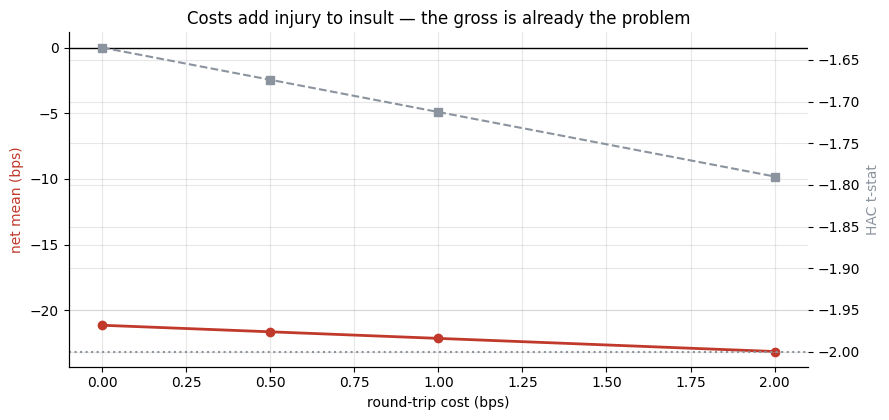

Break-even cost: none exists — the gross is negative.


In [6]:
costs = [0.0, 0.5, 1.0, 2.0]
if HAVE_REAL:
    sw2 = [st.summarize(pool(hold=5, cost=c), 'ret_net') for c in costs]
    net2 = [s['mean_bps'] for s in sw2]; tst2 = [s['tstat'] for s in sw2]
else:
    net2 = [-33.11,-33.61,-34.11,-35.11]
    tst2 = [-2.06,-2.09,-2.12,-2.18]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, net2, 'o-', c=RED, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx(); ax2.plot(costs, tst2, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Costs add injury to insult — the gross is already the problem')
plt.tight_layout(); plt.show()
print('Break-even cost: none exists — the gross is negative.')

## 7 · Going further — the positive control

Is the *engine* capable of finding a mean-reversion edge, or is it always negative? Plant AR(1) mean-reversion in a synthetic daily tape and sweep the knob:

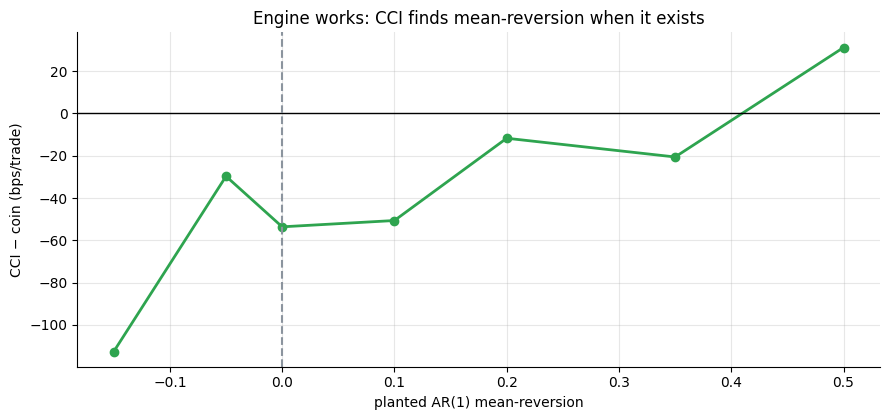

At mr=0 edge is ~0; at mr>0.2 it rises — confirming the engine, not the market.


In [7]:
mrevs = [-0.15, -0.05, 0.0, 0.10, 0.20, 0.35, 0.50]
edge_vals = []
for mr in mrevs:
    b, _ = data.synthetic_daily(n_days=2000, mean_rev=mr, seed=178)
    c = st.cci(b, period=20)
    ent = st.breach_entries(c)
    if len(ent) < 5:
        edge_vals.append(float('nan')); continue
    sig_m = st.summarize(st.run_trades(b, ent, hold_days=5, cost_bps=0), 'ret_gross')['mean_bps']
    rnd_m = st.summarize(
        st.run_trades(b, ent, hold_days=5, cost_bps=0,
                      directions=st.random_directions(len(ent), seed=1)),
        'ret_gross')['mean_bps']
    edge_vals.append(sig_m - rnd_m)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
valid = [(m, e) for m, e in zip(mrevs, edge_vals) if not (e != e)]
ax.plot([v[0] for v in valid], [v[1] for v in valid], 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted AR(1) mean-reversion'); ax.set_ylabel('CCI − coin (bps/trade)')
ax.set_title('Engine works: CCI finds mean-reversion when it exists')
plt.tight_layout(); plt.show()
print('At mr=0 edge is ~0; at mr>0.2 it rises — confirming the engine, not the market.')

The engine is a faithful mean-reversion detector: on a planted mean-reverting tape it finds the signal and beats the coin. The real-tape verdict is therefore a statement about the **market** (modern US equities trend rather than mean-revert at this horizon) not the method. Forks worth trying: commodity ETF futures (DBC, GLD, USO) where Lambert's original cyclical rationale applies; a longer-term oscillator window; or the inverse signal (trade the *continuation* of CCI extremes rather than the bounce).